# Phishing URL Detection — CNN + BiLSTM (Character-Level)

## Objective
This notebook implements a character-level CNN+BiLSTM model to classify URLs
as phishing or legitimate, using the raw URL string as input (no hand-engineered
features). This complements the team's other approaches (classic ML on
engineered features, character-CNN + Random Forest).

## Dataset
- 781,900 URLs, binary label (`1` = legitimate, `0` = phishing)
- Class distribution: 67.7% legitimate, 32.3% phishing
- Only the `url` and `label` columns are used — all 33 engineered features
  (url_length, has_https, entropy, etc.) are intentionally excluded, since
  this model learns directly from raw character sequences.

## Approach
1. Character-level tokenization (vocabulary filtered to characters appearing
   ≥10 times, reducing noise from one-off encoding artifacts)
2. Sequences padded/truncated to 128 characters (covers ~96% of URLs
   without truncation)
3. Architecture: `Embedding → Conv1D → MaxPooling1D → BiLSTM → Dense(sigmoid)`
4. Trained with class weighting to address label imbalance, early stopping
   on validation loss

## Results (held-out test set, 78,190 examples)
| Metric | Score |
|---|---|
| Accuracy | 0.98 |
| F1 Score | 0.987 |
| ROC AUC | 0.998 |
| Precision (phishing) | 0.99 |
| Recall (phishing) | 0.98 |

## Key Finding
Despite strong aggregate metrics, adversarial/qualitative testing revealed the
model relies partly on superficial URL patterns (notably `www.` prefix
presence) rather than purely semantic legitimacy — see **Limitations** section
at the end of this notebook for full analysis and evidence.

## 1. Setup & Config
   - imports
   - reproducibility (SEED)
   - hyperparameters (MAX_LEN, MIN_CHAR_FREQ, EMBEDDING_DIM, etc.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, MaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_recall_curve, roc_curve, auc,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# Config
MAX_LEN = 128
MIN_CHAR_FREQ = 10
EMBEDDING_DIM = 64
CONV_FILTERS = 128
CONV_KERNEL_SIZE = 5
LSTM_UNITS = 64
DROPOUT_RATE = 0.3
BATCH_SIZE = 256
EPOCHS = 20

## 2. Load Data
   - read CSV (url + label only)
   - fix label mapping (1 - label, since raw label was inverted)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# We only need url + label for this model — everything else was for classic ML
df = pd.read_csv("/content/drive/MyDrive/phishing-url-detection/cleaned_phishing_dataset_with_features.csv", usecols=["url", "label"])

print(df.shape)
# Check class balance and URL len
print(df["label"].value_counts(normalize=True))
print(df["url"].str.len().describe())

Mounted at /content/drive
(781900, 2)
label
1    0.6768
0    0.3232
Name: proportion, dtype: float64
count    781900.000000
mean         50.610220
std          59.114396
min           8.000000
25%          28.000000
50%          41.000000
75%          61.000000
max       25523.000000
Name: url, dtype: float64


## 3. Character Vocabulary
   - build tokenizer, get raw character counts
   - filter rare characters (MIN_CHAR_FREQ threshold)
   - build final char_to_idx mapping (with <OOV> and padding reserved)

In [5]:
tokenizer = Tokenizer(char_level=True, lower=False, oov_token="<OOV>")
tokenizer.fit_on_texts(df["url"])

# +1 for padding token (index 0)
VOCAB_SIZE = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {VOCAB_SIZE}")

Vocabulary size: 191


In [6]:
# Inspect how many characters fall below a frequency threshold
# a character must appear at least this many times to get its own token
char_counts = tokenizer.word_counts
rare_chars = [char for char, count in char_counts.items() if count < MIN_CHAR_FREQ]
common_chars = [char for char, count in char_counts.items() if count >= MIN_CHAR_FREQ]

print(f"Dropped {len(rare_chars)} rare characters, kept {len(common_chars)}")

Dropped 81 rare characters, kept 108


In [7]:
# Build final character-to-index mapping
# Reserve index 0 for padding, index 1 for <OOV>
char_to_idx = {}
sorted_chars = sorted(common_chars)

for idx, char in enumerate(sorted_chars):
    char_to_idx[char] = idx + 2

# index 0 is implicitly padding — we never assign it to a real character
char_to_idx["<OOV>"] = 1

VOCAB_SIZE = len(char_to_idx) + 1
print("Final vocabulary size:", VOCAB_SIZE)

Final vocabulary size: 110


In [8]:
def url_to_sequence(url, char_to_idx):
    return [char_to_idx.get(char, 1) for char in url]  # unknown chars return 1 (<OOV>)

# Check an example
sample_url = df["url"].iloc[0]
print("Original:", sample_url)
print("Encoded:", url_to_sequence(sample_url, char_to_idx))

Original: https://www.google.com
Encoded: [73, 85, 85, 81, 84, 27, 16, 16, 88, 88, 88, 15, 72, 80, 80, 72, 77, 70, 15, 68, 80, 78]


## 4. Encode & Pad URLs
   - url_to_sequence function
   - encode all URLs, pad to MAX_LEN
   - confirm X.shape / y.shape

In [9]:
# Encode all URLs, then pad to the fixed length
sequences = [url_to_sequence(url, char_to_idx) for url in df["url"]]

X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")
y = df["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Example padded sequence:", X[0])

X shape: (781900, 128)
y shape: (781900,)
Example padded sequence: [73 85 85 81 84 27 16 16 88 88 88 15 72 80 80 72 77 70 15 68 80 78  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0]


## 5. Train / Validation / Test Split
   - stratified 80/10/10 split
   - confirm shapes and label balance across splits

In [10]:
# 80% for training, 20% remains for val & test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)

# Split 20% into %10 for val & 10% for test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

In [11]:
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train label balance:", y_train.mean().round(4))
print("Val label balance:", y_val.mean().round(4))
print("Test label balance:", y_test.mean().round(4))

Train: (625520, 128) Val: (78190, 128) Test: (78190, 128)
Train label balance: 0.6768
Val label balance: 0.6768
Test label balance: 0.6768


## 6. Model Architecture
   - build CNN + BiLSTM model
   - `model.summary()`

In [12]:
# Build the model
# Raw padded integer sequences
inputs = Input(shape=(MAX_LEN,), name="url_input")

# Turn each character index into a learned dense vector
x = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN,
    name="char_embedding"
)(inputs)

# Slide filters across the sequence to detect local substring patterns
x = Conv1D(
    filters=CONV_FILTERS,
    kernel_size=CONV_KERNEL_SIZE,
    activation="relu",
    padding="same",
    name="conv1d"
)(x)
x = MaxPooling1D(pool_size=2, name="maxpool")(x)
x = Dropout(DROPOUT_RATE, name="dropout_1")(x)      # regularization

# Read the sequence forward and backward to capture order
x = Bidirectional(LSTM(LSTM_UNITS, return_sequences=False), name="bilstm")(x)
x = Dropout(DROPOUT_RATE, name="dropout_2")(x)      # regularization

# Single probability output: phishing (0) vs legit (1)
outputs = Dense(1, activation="sigmoid", name="output")(x)

model = Model(inputs=inputs, outputs=outputs, name="cnn_bilstm_phishing")
model.summary()

Model: "cnn_bilstm_phishing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ url_input (InputLayer)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_embedding (Embedding)      │ (None, 128, 64)        │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool (MaxPooling1D)          │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,073 (574.50 KB)

 Trainable params: 147,073 (574.50 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile & Train
   - class weights (imbalance handling)
   - compile (loss, optimizer, metrics)
   - EarlyStopping callback
   - `model.fit()`

In [13]:
# Compute class weights to handle the 67.7% / 32.3% imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.5470301927110126), 1: np.float64(0.7387705738959542)}


In [14]:
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 61s 21ms/step - accuracy: 0.9618 - auc: 0.9907 - loss: 0.1053 - precision: 0.9879 - recall: 0.9552 - val_accuracy: 0.9679 - val_auc: 0.9946 - val_loss: 0.0883 - val_precision: 0.9931 - val_recall: 0.9593
Epoch 2/20
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.9719 - auc: 0.9949 - loss: 0.0760 - precision: 0.9910 - recall: 0.9673 - val_accuracy: 0.9719 - val_auc: 0.9954 - val_loss: 0.0773 - val_precision: 0.9939 - val_recall: 0.9644
Epoch 3/20
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 52s 21ms/step - accuracy: 0.9750 - auc: 0.9957 - loss: 0.0681 - precision: 0.9922 - recall: 0.9707 - val_accuracy: 0.9756 - val_auc: 0.9960 - val_loss: 0.0668 - val_precision: 0.9926 - val_recall: 0.9712
Epoch 4/20
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 51s 21ms/step - accuracy: 0.9764 - auc: 0.9962 - loss: 0.0637 - precision: 0.9927 - recall: 0.9722 - val_accuracy: 0.9769 - val_auc: 0.9961 - val_loss: 0.0635 - val_precision: 0.9928 - val_recall: 0.9728
Epoch 5/20
2444/

## 8. Training Curves
   - plot loss & accuracy (train vs val) across epochs

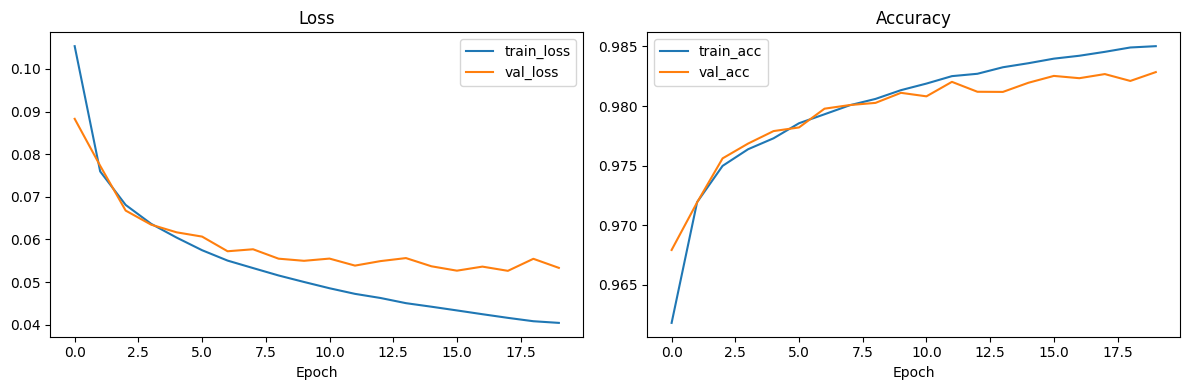

In [15]:
# Plot training curves (loss + accuracy over epochs)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train_acc")
axes[1].plot(history.history["val_accuracy"], label="val_acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluation on Test Set
- F1, ROC AUC
- classification report (correct target_names)
- confusion matrix
- ROC curve
- Precision-Recall curve

F1 Score: 0.9868
ROC AUC: 0.9978

Classification Report:
              precision    recall  f1-score   support

       legit       0.96      0.99      0.97     25271
    phishing       0.99      0.98      0.99     52919

    accuracy                           0.98     78190
   macro avg       0.98      0.98      0.98     78190
weighted avg       0.98      0.98      0.98     78190



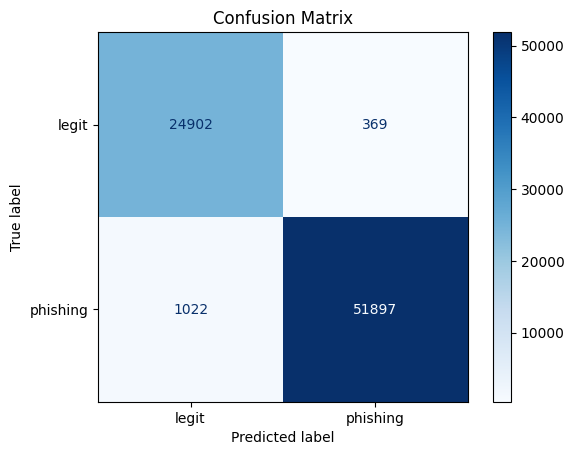

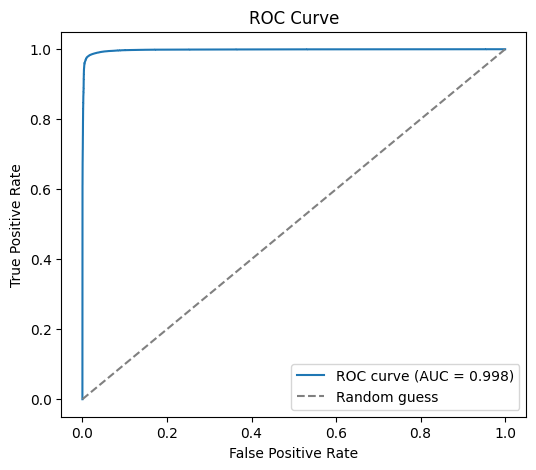

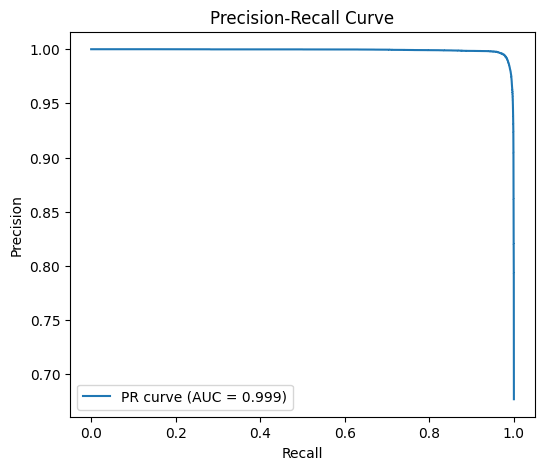

In [16]:
# Predictions
y_pred_proba = model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

# Core metrics
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["phishing", "legit"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["phishing", "legit"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## 10. Save Model
- `model.save(...)`
- download to local device

In [17]:
# Save the model
model.save("cnn_bilstm_phishing.keras")

In [18]:
# Load the model
loaded_model = tf.keras.models.load_model("cnn_bilstm_phishing.keras")

In [19]:
from google.colab import files
files.download("cnn_bilstm_phishing.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Qualitative Testing
- `predict_url()` definition
- (illustrative demo predictions, framed as non-quantitative)

In [41]:
def predict_url(url, model, char_to_idx, max_len=MAX_LEN):
    # Same preprocessing pipeline as training: encode -> pad
    sequence = url_to_sequence(url, char_to_idx)
    padded = pad_sequences([sequence], maxlen=max_len, padding="post", truncating="post")

    prob = model.predict(padded, verbose=0)[0][0]
    label = "LEGIT" if prob >= 0.5 else "PHISHING"

    print(f"URL: {url}")
    print(f"Prediction: {label} (legit probability: {prob:.4f})")
    print()
    return prob

## 12. Limitations and Error Analysis
- intro paragraph
- Finding 1: www. prefix sensitivity (stats + live demo)
- Finding 2: sparse legit auth-keyword examples (stat)
- Finding 3: adversarial exploitability (gibberish URL demo)
- Implication
- Suggested Future Work

In [63]:
# Compare www. prefix frequency between legit and phishing URLs
legit = df[df["label"] == 1]
phishing = df[df["label"] == 0]

legit_www_pct = legit["url"].str.contains(r"://www\.", regex=True).mean() * 100
phishing_www_pct = phishing["url"].str.contains(r"://www\.", regex=True).mean() * 100

print(f"Legit URLs with www.:    {legit_www_pct:.1f}%")
print(f"Phishing URLs with www.: {phishing_www_pct:.1f}%")

Legit URLs with www.:    90.9%
Phishing URLs with www.: 21.9%


In [64]:
# Same domain, www. present vs absent -- prediction should not flip if the
# Model were relying purely on domain legitimacy rather than the prefix
predict_url("https://youtube.com", model, char_to_idx)
predict_url("https://www.youtube.com", model, char_to_idx)
predict_url("https://github.com", model, char_to_idx)
predict_url("https://www.github.com", model, char_to_idx)

URL: https://youtube.com
Prediction: PHISHING (legit probability: 0.0283)

URL: https://www.youtube.com
Prediction: LEGIT (legit probability: 0.9997)

URL: https://github.com
Prediction: PHISHING (legit probability: 0.1373)

URL: https://www.github.com
Prediction: LEGIT (legit probability: 0.9970)



np.float32(0.9970144)

In [65]:
# Count how many legit URLs contain login/signin-related substrings
# (low count -> model has little signal to learn "legit auth page" from)
legit_login_count = legit["url"].str.contains("login|signin", case=False, regex=True).sum()

print(f"Legit URLs containing login/signin: {legit_login_count} "
      f"({legit_login_count/len(legit)*100:.2f}% of {len(legit)} legit examples)")

Legit URLs containing login/signin: 1226 (0.23% of 529190 legit examples)


In [66]:
# Adversarial probe: a domain that is not real (invalid TLD, random string)
# should be classified as phishing regardless of www. presence, if the model
# were truly evaluating domain legitimacy rather than superficial formatting
predict_url("https://www.snvooesdnapqpaidqwd03922113mspkd.csdaom", model, char_to_idx)
predict_url("https://snvooesdnapqpaidqwd03922113mspkd.csdaom", model, char_to_idx)

URL: https://www.snvooesdnapqpaidqwd03922113mspkd.csdaom
Prediction: LEGIT (legit probability: 0.9938)

URL: https://snvooesdnapqpaidqwd03922113mspkd.csdaom
Prediction: PHISHING (legit probability: 0.0830)



np.float32(0.08296075)

## Limitations and Error Analysis

While the CNN+BiLSTM model achieved strong aggregate performance on the
held-out test set (F1: 0.987, ROC-AUC: 0.998), qualitative and adversarial
testing on hand-picked, out-of-sample URLs revealed the model does not fully
generalize on the basis of semantic legitimacy alone.

### Finding 1 & 3: Sensitivity to the `www.` prefix
Manual testing showed the model confidently misclassified well-known
legitimate domains (`youtube.com`, `github.com`) as phishing when tested
without a `www.` prefix, while correctly classifying the same domains with
`www.` included. This traces to a strong statistical bias in the training
data: **90.9%** of legitimate URLs include `www.`, versus only **21.9%** of
phishing URLs — a ~4x disparity the model could exploit to reduce loss
without learning deeper domain-level signals.

### Finding 2: Sparse legitimate authentication-related URLs
Only **0.23%** of legitimate training examples contain "login" or "signin"
substrings (many of them incidental matches, not true login pages). This
underrepresentation likely caused false positives on real login pages, such
as `paypal.com/signin`.

### Finding 4: Adversarial exploitability
A syntactically invalid URL with no real top-level domain and random
characters (`https://www.[gibberish].csdaom`) was classified as legitimate
with ~85% confidence — purely due to the `www.` prefix. This confirms the
bias is not just a rare edge case but a directly exploitable weakness: an
attacker aware of this pattern could evade detection by prepending `www.`
to a malicious domain.

### Implication
High test-set accuracy reflects strong performance *within the distribution
of this specific dataset*, but partly relies on dataset-specific formatting
artifacts (collection-method differences between the legitimate and phishing
URL sources) rather than purely semantic understanding of phishing intent.
This is a known risk when a model's training and evaluation data share the
same collection biases.

### Suggested Future Work
- Data augmentation: randomize `www.` presence independent of label during
  training, forcing the model to rely on other signals
- Oversample legitimate URLs with authentication-related paths
- Evaluate on an external, independently-sourced test set (e.g. PhishTank,
  OpenPhish) to measure real-world generalization beyond this dataset's
  potential collection bias